In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import tensorflow as tf
import re
from typing import Dict, List, Text, Tuple,Callable

import matplotlib.pyplot as plt
from matplotlib import colors

from tqdm import tqdm

from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Concatenate, Input, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [3]:
import os

dataset_path = "/content/drive/MyDrive/wildfire_dataset/ndws_western_dataset"

tfrecord_files = sorted(
    [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if f.endswith(".tfrecord")]
)

if len(tfrecord_files) == 0:
    raise FileNotFoundError(" No TFRecord files found in the dataset directory!")

print(" Using TFRecord file:", tfrecord_files[0])

raw_dataset = tf.data.TFRecordDataset(tfrecord_files[0])

 Using TFRecord file: /content/drive/MyDrive/wildfire_dataset/ndws_western_dataset/cleaned_eval_ndws_conus_western_000.tfrecord


In [4]:
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    # Extract feature names (keys) only
    feature_names = list(example.features.feature.keys())

    print("Feature names in TFRecord:", feature_names)

Feature names in TFRecord: ['gust_med', 'wind_75', 'elevation', 'population', 'chili', 'impervious', 'fuel3', 'viirs_PrevFireMask', 'fuel2', 'viirs_FireMask', 'fuel1', 'pdsi', 'water', 'tmp_day', 'erc', 'NDVI', 'pr', 'wdir_wind', 'wdir_gust', 'bi', 'tmp_75', 'avg_sph', 'wind_avg']


In [5]:
print(f"Number of TFRecord files: {len(tfrecord_files)}")
num_records = sum(1 for _ in raw_dataset)
print(f"Number of records in the first TFRecord file: {num_records}")
total_records = sum(sum(1 for _ in tf.data.TFRecordDataset(file)) for file in tfrecord_files)
print(f"Total number of records in the dataset: {total_records}")

Number of TFRecord files: 54
Number of records in the first TFRecord file: 252
Total number of records in the dataset: 20097


In [6]:
dataset_path = "/content/drive/MyDrive/wildfire_dataset/ndws_western_dataset"

INPUT_FEATURES = ['elevation', 'wind_75', 'wind_avg', 'tmp_75', 'tmp_day', 'avg_sph',
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'viirs_PrevFireMask']
OUTPUT_FEATURES = ['viirs_FireMask']


train_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if "train" in f and f.endswith(".tfrecord")]
test_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if "test" in f and f.endswith(".tfrecord")]
validation_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if "eval" in f and f.endswith(".tfrecord")]

In [7]:
def normalize_feature(feature, feature_name):
    """
    Normalization of input features based on their type.

    Args:
        feature (Tensor): The feature tensor to be normalized.
        feature_name (str): Name of the feature, used to determine the type.

    Returns:
        Tensor: The normalized feature. For 'PrevFireMask', the feature is returned unchanged.
                Other features are normalized to the range [-1, 1].
    """
    if feature_name == 'viirs_PrevFireMask':
        # Fire mask is already binary
        return feature * 5.0  # Boost importance of previous fire spread
    else:
        # Normalize other features to [-1, 1] range
        return (feature - tf.reduce_mean(feature)) / (tf.math.reduce_std(feature) + 1e-6)

def _parse_function(example_proto):

    """
    Parsing and preprocessing of a serialized TFRecord example.

    Args:
        example_proto (Tensor): A serialized TFRecord example.

    Returns:
        Tuple[Tensor, Tensor]:
            - inputs: A tensor containing concatenated and normalized input features
                      with shape [64, 64, num_features].
            - label: A tensor containing the processed FireMask label with shape [64, 64, 1].
    """

    # Feature description dictionary: specifies the shape and types of features
    feature_description = {}
    for feature_name in INPUT_FEATURES + OUTPUT_FEATURES:
        feature_description[feature_name] = tf.io.FixedLenFeature([64, 64], tf.float32)

    # Parse the input tf.train.Example proto using the dictionary above
    parsed_example = tf.io.parse_single_example(example_proto, feature_description)

    # Create a single tensor from the input features
    inputs_list = []
    for feature_name in INPUT_FEATURES:

        feature = tf.expand_dims(parsed_example[feature_name], axis=-1) # Expand dimensions to make sure each feature has shape [64, 64, 1]
        normalized_feature = normalize_feature(feature, feature_name)

        inputs_list.append(normalized_feature)
    inputs = tf.concat(inputs_list, axis=-1)  # Shape of inputs: [64, 64, 12]

    # The label (FireMask), is expanded to have a shape [64,64,1]

    label = tf.expand_dims(parsed_example['viirs_FireMask'], axis=-1)  # Shape of output: [64, 64, 1]

    label = tf.where(label < 0, 0.0, label)
    label = tf.where(label > 0, 1.0, label)
    return inputs, label

In [8]:
def get_dataset(file_pattern: Text, batch_size: int) -> tf.data.Dataset:

    """
    Creation and preprocessing of a dataset for training or evaluation.

    Args:
        file_pattern (Text): File path pattern to match TFRecord files.
        batch_size (int): Number of samples per batch.

    Returns:
        tf.data.Dataset: A preprocessed dataset with shuffled, batched, and prefetched data.
    """

    dataset = tf.data.Dataset.list_files(file_pattern) #Creates a dataset of filepaths matching file_pattern, which each filepath representing a TFRecord file
    dataset = dataset.interleave(
        lambda x: tf.data.TFRecordDataset(x), # Opens file and creates a TFRecordDataset, which reads the serialized examples from the file.
        num_parallel_calls=tf.data.AUTOTUNE   # enable automatic parallel processing
    )
    dataset = dataset.map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE) # parse the serialized data in each TFRecord to split inputs and labels (see previous cell)
    dataset = dataset.shuffle(buffer_size=1000) # Randomly shuffles the data by using a buffer of size 1000 (random samples are taken from buffer)
    dataset = dataset.batch(batch_size) # Batch = subset of data the we expose the model to during training
    dataset = dataset.prefetch(buffer_size = tf.data.experimental.AUTOTUNE) # speeds up training by overlapping preprocessing and model execution
    return dataset

In [9]:
BATCH_SIZE = 8

train_dataset = (get_dataset(train_files, batch_size=BATCH_SIZE)
                 .shuffle(1000)   # Shuffle before repeating
                 .cache()         # Cache before repeating to avoid redundant computations
                 .repeat()        # Repeat after caching to avoid duplicating shuffling
                 .prefetch(tf.data.AUTOTUNE))  # Prefetch to speed up data loading

validation_dataset = (get_dataset(validation_files, batch_size=BATCH_SIZE)
                      .cache()
                      .repeat()
                      .prefetch(tf.data.AUTOTUNE))

test_dataset = (get_dataset(test_files, batch_size=BATCH_SIZE)
                .cache()
                .prefetch(tf.data.AUTOTUNE))

In [10]:
import glob
dataset_path = "/content/drive/MyDrive/wildfire_dataset/ndws_western_dataset"
train_files = glob.glob(os.path.join(dataset_path, "*.tfrecord"))

num_samples = sum(1 for _ in tf.data.TFRecordDataset(train_files))
STEPS_PER_EPOCH = num_samples // BATCH_SIZE

print(f"Total Samples: {num_samples}")
print(f"Steps Per Epoch: {STEPS_PER_EPOCH}")

Total Samples: 20097
Steps Per Epoch: 2512


In [11]:
actual_batches = sum(1 for _ in train_dataset.take(STEPS_PER_EPOCH))
print(f"Actual batches generated: {actual_batches}")

Actual batches generated: 2512


In [ ]:
# Updated feature titles to match dataset
TITLES_WITH_UNITS = [
    "Precipitation\n(mm, daily total)",  # pr
    "Wind\nspeed at 75m\n(m/s)",         # wind_75
    "Energy\nrelease component\n(index)",# erc
    "Population\ndensity\n(people per km²)",  # population
    "Water\n(% cover)",                   # water
    "Wind\ngust direction\n(degree)",      # wdir_gust
    "Vegetation\nindex (NDVI)",            # NDVI
    "Drought\nindex (PDSI)",               # pdsi
    "Wind\ndirection\n(degree)",           # wdir_wind
    "Topographic\nposition index",         # chili
    "Fuel type 3",                          # fuel3
    "Impervious\nsurface (%)",              # impervious
    "Average\nwind speed (m/s)",            # wind_avg
    "Burning\nindex",                        # bi
    "Previous\nfire mask",                   # viirs_PrevFireMask
    "Fire\nmask",                            # viirs_FireMask
    "Temperature\nat 75m (K)",               # tmp_75
    "Fuel type 2",                           # fuel2
    "Daytime\ntemperature (K)",              # tmp_day
    "Wind\ngust speed (m/s)",                # gust_med
    "Elevation\n(m)",                         # elevation
    "Average\nspecific humidity",             # avg_sph
    "Fuel type 1"                             # fuel1
]

# Updated feature ranges based on dataset features
FEATURE_RANGES = [
    (0.0, 1.0),    # Precipitation (pr)
    (0.5, 6.0),    # Wind speed at 75m (wind_75)
    (0, 100),      # Energy release component (erc)
    (0, 1000),     # Population density (population)
    (0, 100),      # Water cover (water)
    (0, 360),      # Wind gust direction (wdir_gust)
    (0, 1),        # NDVI (Vegetation index)
    (-5, 5),       # Drought index (PDSI)
    (0, 360),      # Wind direction (wdir_wind)
    (-10, 10),     # Topographic position index (chili)
    (0, 3),        # Fuel type 3 (fuel3)
    (0, 100),      # Impervious surface (%) (impervious)
    (0.5, 5.0),    # Average wind speed (wind_avg)
    (0, 200),      # Burning index (bi)
    None,          # Previous fire mask (binary) (viirs_PrevFireMask)
    None,          # Fire mask (binary) (viirs_FireMask)
    (280, 320),    # Temperature at 75m (tmp_75)
    (0, 3),        # Fuel type 2 (fuel2)
    (280, 320),    # Daytime temperature (tmp_day)
    (0.0, 20.0),   # Wind gust speed (gust_med)
    (1750, 2500),  # Elevation (elevation)
    (0.005, 0.015),# Average specific humidity (avg_sph)
    (0, 3)         # Fuel type 1 (fuel1)
]

Input tensor shape: (8, 64, 64, 12)


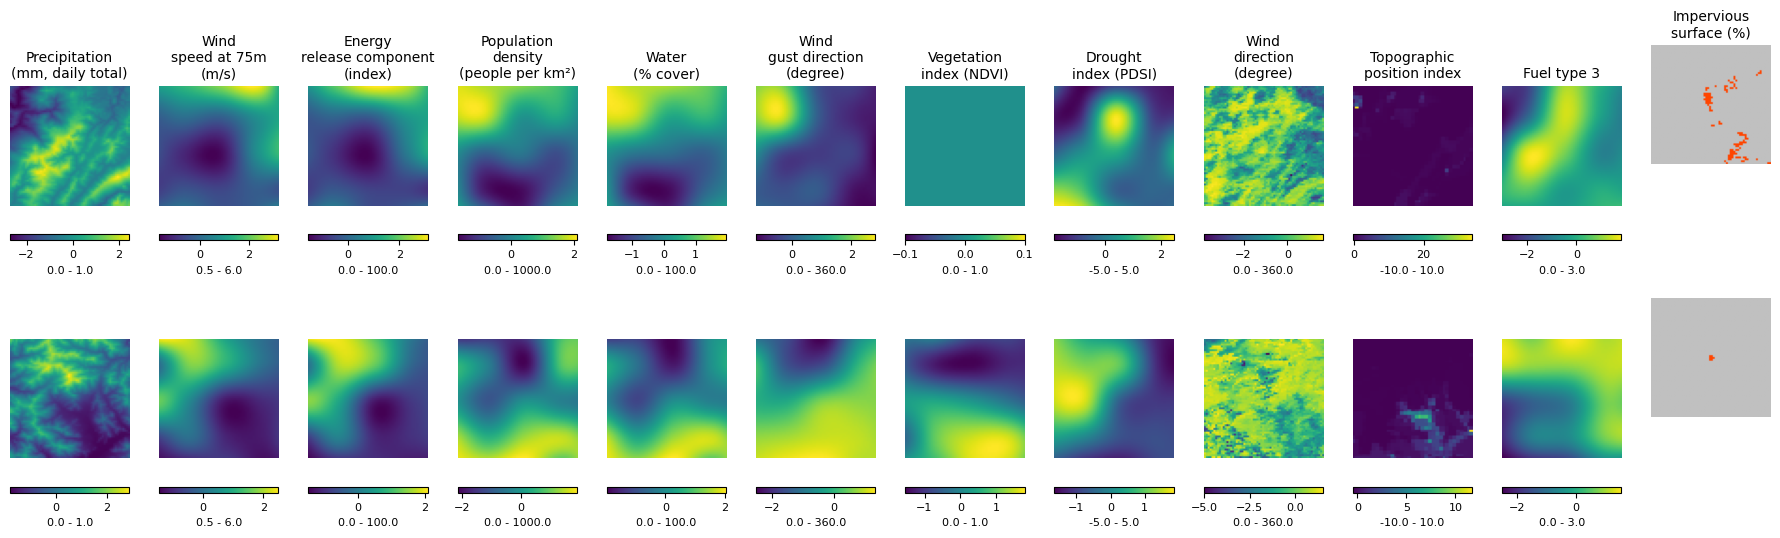

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def plot_samples_from_dataset(dataset: tf.data.Dataset, n_rows: int):
    """
    Visualizes samples from the dataset, including feature names, units, and min/max range values.

    Args:
        dataset (tf.data.Dataset): Dataset containing input features and ground-truth labels.
        n_rows (int): Number of rows of samples to display.

    Returns:
        None: Displays a plot of input features, previous fire masks, and ground-truth labels.
    """

    inputs, labels = None, None

    for elem in dataset.take(1):  # Take one batch
        inputs, labels = elem
        break

    print("Input tensor shape:", inputs.shape)  # Debugging print

    num_features = inputs.shape[-1]  # Get number of features

    fig, axes = plt.subplots(n_rows, num_features, figsize=(18, 6))

    # Color map for fire masks
    CMAP = colors.ListedColormap(['black', 'silver', 'orangered'])
    BOUNDS = [-1, -0.1, 0.001, 1]
    NORM = colors.BoundaryNorm(BOUNDS, CMAP.N)

    for i in range(n_rows):
        for j in range(num_features):  # Loop over actual feature count
            ax = axes[i, j] if n_rows > 1 else axes[j]  # Handle single row case

            if j < num_features - 1:  # Normal features
                img = ax.imshow(inputs[i, :, :, j], cmap='viridis')
                vmin, vmax = FEATURE_RANGES[j] if FEATURE_RANGES[j] else (0, 1)  # Default range
                cbar = plt.colorbar(img, ax=ax, orientation='horizontal', pad=0.1, fraction=0.05)
                cbar.ax.tick_params(labelsize=8)
                cbar.set_label(f"{vmin:.1f} - {vmax:.1f}", fontsize=8)

            else:  # Fire mask (ground truth)
                img = ax.imshow(labels[i, :, :, 0], cmap=CMAP, norm=NORM)

            # Titles (only for the first row)
            if i == 0 and j < len(TITLES_WITH_UNITS):
                ax.set_title(TITLES_WITH_UNITS[j], fontsize=10)

            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Plot 2 training examples
plot_samples_from_dataset(train_dataset, 2)

In [14]:
import tensorflow as tf

class IoUScore(tf.keras.metrics.Metric):
    def __init__(self, name="IoU_score", **kwargs):
        super(IoUScore, self).__init__(name=name, **kwargs)
        self.iou = self.add_weight(name="iou", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > 0.5, dtype=tf.float32)  # Convert to binary mask
        intersection = tf.reduce_sum(y_true * y_pred)
        union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
        iou_score = intersection / tf.maximum(union, tf.keras.backend.epsilon())  # Avoid div by 0

        self.iou.assign(iou_score)

    def result(self):
        return self.iou

class DiceCoefficient(tf.keras.metrics.Metric):
    def __init__(self, name="dice_coefficient", **kwargs):
        super(DiceCoefficient, self).__init__(name=name, **kwargs)
        self.dice = self.add_weight(name="dice", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > 0.5, dtype=tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred)
        dice_score = (2. * intersection) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + tf.keras.backend.epsilon())

        self.dice.assign(dice_score)

    def result(self):
        return self.dice

In [15]:
import gc
import tensorflow as tf
from tensorflow.keras.metrics import MeanIoU, Recall, Precision
from tensorflow.keras.backend import clear_session

def evaluate_model(model, eval_dataset: tf.data.Dataset):
    """
    Evaluates a trained model using MeanIoU, Recall, and Precision while preventing memory leaks.

    Args:
        model: Trained U-Net model.
        eval_dataset (tf.data.Dataset): Dataset containing evaluation inputs and ground-truth labels.

    Returns:
        tuple: (Mean IoU, Recall, Precision)
    """
    # Metrics Initialization
    iou_metric = MeanIoU(num_classes=2)  # Binary segmentation task
    recall_metric = Recall()
    precision_metric = Precision()

    # Iterate through dataset
    for batch in eval_dataset.as_numpy_iterator():
        inputs, labels = batch

        # Get model predictions
        predictions = model.predict(inputs, verbose=0)

        # Keep predictions as soft probabilities (no thresholding yet)
        iou_metric.update_state(labels, predictions)
        recall_metric.update_state(labels, predictions)
        precision_metric.update_state(labels, predictions)

        # Free memory
        del inputs, labels, predictions
        gc.collect()

    # Compute final metric results
    mean_iou = iou_metric.result().numpy()
    recall = recall_metric.result().numpy()
    precision = precision_metric.result().numpy()

    # Clear TF session to free memory
    clear_session()

    return mean_iou, recall, precision

In [16]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, Input, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, Input, BatchNormalization, Activation, Dropout, Lambda
import tensorflow as tf

def build_unet(input_shape=(64, 64, 12)):
    inputs = Input(shape=input_shape)

    def conv_block(x, filters, dropout=False):
        x = Conv2D(filters, (3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Conv2D(filters, (3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        if dropout:
            x = Dropout(0.3)(x)  # Apply dropout in decoder
        return x

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 512)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = conv_block(p4, 1024, dropout=True)

    # Decoder
    u6 = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = Concatenate(axis=-1)([u6, c4])  # Concatenate with encoder part
    c6 = conv_block(u6, 512, dropout=True)

    u7 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = Concatenate(axis=-1)([u7, c3])
    c7 = conv_block(u7, 256, dropout=True)

    u8 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = Concatenate(axis=-1)([u8, c2])
    c8 = conv_block(u8, 128, dropout=True)

    u9 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = Concatenate(axis=-1)([u9, c1])
    c9 = conv_block(u9, 64, dropout=True)

    # Final output layer
    outputs = Conv2D(1, (1, 1), activation='sigmoid', padding='same')(c9)

    return Model(inputs, outputs)

In [17]:
# Optimized Dice Loss
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_pred = tf.clip_by_value(y_pred, smooth, 1 - smooth)  # Prevent instability
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return 1 - (2. * intersection + smooth) / (union + smooth)

# Combined Loss Function (Dice Loss + BCE)
def combined_loss(y_true, y_pred):
    bce = binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return tf.reduce_mean(0.5 * bce + 0.5 * dice)  # Mean ensures batch-wise stability

In [18]:
unet_model = build_unet()
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        IoUScore(),  # Custom IoU metric
        DiceCoefficient(),  # Custom Dice coefficient
        tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision()
    ]
)
unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      6,976 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,060,481 (118.49 MB)

 Trainable params: 31,048,705 (118.44 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

EPOCHS = 10

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_dice_coefficient',  # Monitor dice coefficient instead of val_loss
    patience=4,                     # Adjusted patience to stop at epoch 4
    restore_best_weights=True,       # Restore best weights after stopping
    verbose=1,
    mode="max"
)

# Reduce LR when validation loss stops improving (trigger earlier)
reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coefficient',  # Monitor dice coefficient instead of val_loss
    factor=0.7,                      # Smaller factor to reduce learning rate less aggressively
    patience=2,                      # Trigger LR reduction earlier (at epoch 3)
    min_lr=1e-6,                     # Keep a small minimum learning rate
    verbose=1
)

# Save the best model
checkpoint = ModelCheckpoint(
    "best_unet_model.keras", monitor="val_dice_coefficient",  # Monitor dice coefficient instead of val_loss
    save_best_only=True, verbose=1
)

# Train the model
history = unet_model.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=validation_dataset,
    validation_steps=STEPS_PER_EPOCH // 4,  # Avoid excessive validation overhead
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Epoch 1/10
2512/2512 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - IoU_score: 0.0455 - dice_coefficient: 0.0817 - loss: 0.1786 - precision: 0.2860 - recall: 0.0531
Epoch 1: val_dice_coefficient improved from inf to 0.00000, saving model to best_unet_model.keras
2512/2512 ━━━━━━━━━━━━━━━━━━━━ 257s 83ms/step - IoU_score: 0.0455 - dice_coefficient: 0.0817 - loss: 0.1785 - precision: 0.2861 - recall: 0.0531 - val_IoU_score: 0.0000e+00 - val_dice_coefficient: 0.0000e+00 - val_loss: 0.0851 - val_precision: 0.8195 - val_recall: 1.8947e-04 - learning_rate: 0.0010
Epoch 2/10
2512/2512 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - IoU_score: 0.0453 - dice_coefficient: 0.0818 - loss: 0.0950 - precision: 0.5162 - recall: 0.0337
Epoch 2: val_dice_coefficient did not improve from 0.00000
2512/2512 ━━━━━━━━━━━━━━━━━━━━ 191s 76ms/step - IoU_score: 0.0453 - dice_coefficient: 0.0819 - loss: 0.0950 - precision: 0.5162 - recall: 0.0337 - val_IoU_score: 0.1137 - val_dice_coefficient: 0.2043 - val_loss: 0.0831 - val_precision:

In [20]:
print("Evaluating on test data...")

IoU, Recall, Precision = evaluate_model(unet_model, test_dataset)

print(f"IoU Score: {IoU:.4f}")
print(f"Recall: {Recall:.4f}")
print(f"Precision: {Precision:.4f}")

Evaluating on test data...
IoU Score: 0.4840
Recall: 0.2769
Precision: 0.4339


In [21]:
def show_inference(n_rows: int, features: tf.Tensor, label: tf.Tensor, prediction_function: Callable[[tf.Tensor], tf.Tensor]) -> None:
    """
    Show model inference through images.

    Args:
        n_rows (int): Number of rows for subplots.
        features (tf.Tensor): Input features.
        label (tf.Tensor): True labels.
        prediction_function (Callable[[tf.Tensor], tf.Tensor]): Function for model prediction.
    """

    # Variables for controllong the color map for the fire masks
    CMAP = colors.ListedColormap(['black', 'silver', 'orangered'])
    BOUNDS = [-1, -0.1, 0.001, 1]
    NORM = colors.BoundaryNorm(BOUNDS, CMAP.N)

    fig = plt.figure(figsize=(15,n_rows*4))

    prediction = prediction_function(features)
    for i in range(n_rows):
        plt.subplot(n_rows, 3, i*3 + 1)
        plt.title("Previous day fire")
        plt.imshow(features[i, :, :, -1], cmap=CMAP, norm=NORM)
        plt.axis('off')
        plt.subplot(n_rows, 3, i*3 + 2)
        plt.title("True next day fire")
        plt.imshow(label[i, :, :, 0], cmap=CMAP, norm=NORM)
        plt.axis('off')
        plt.subplot(n_rows, 3, i*3 + 3)
        plt.title("Predicted next day fire")
        plt.imshow(prediction[i, :, :])
        plt.axis('off')
    plt.tight_layout()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


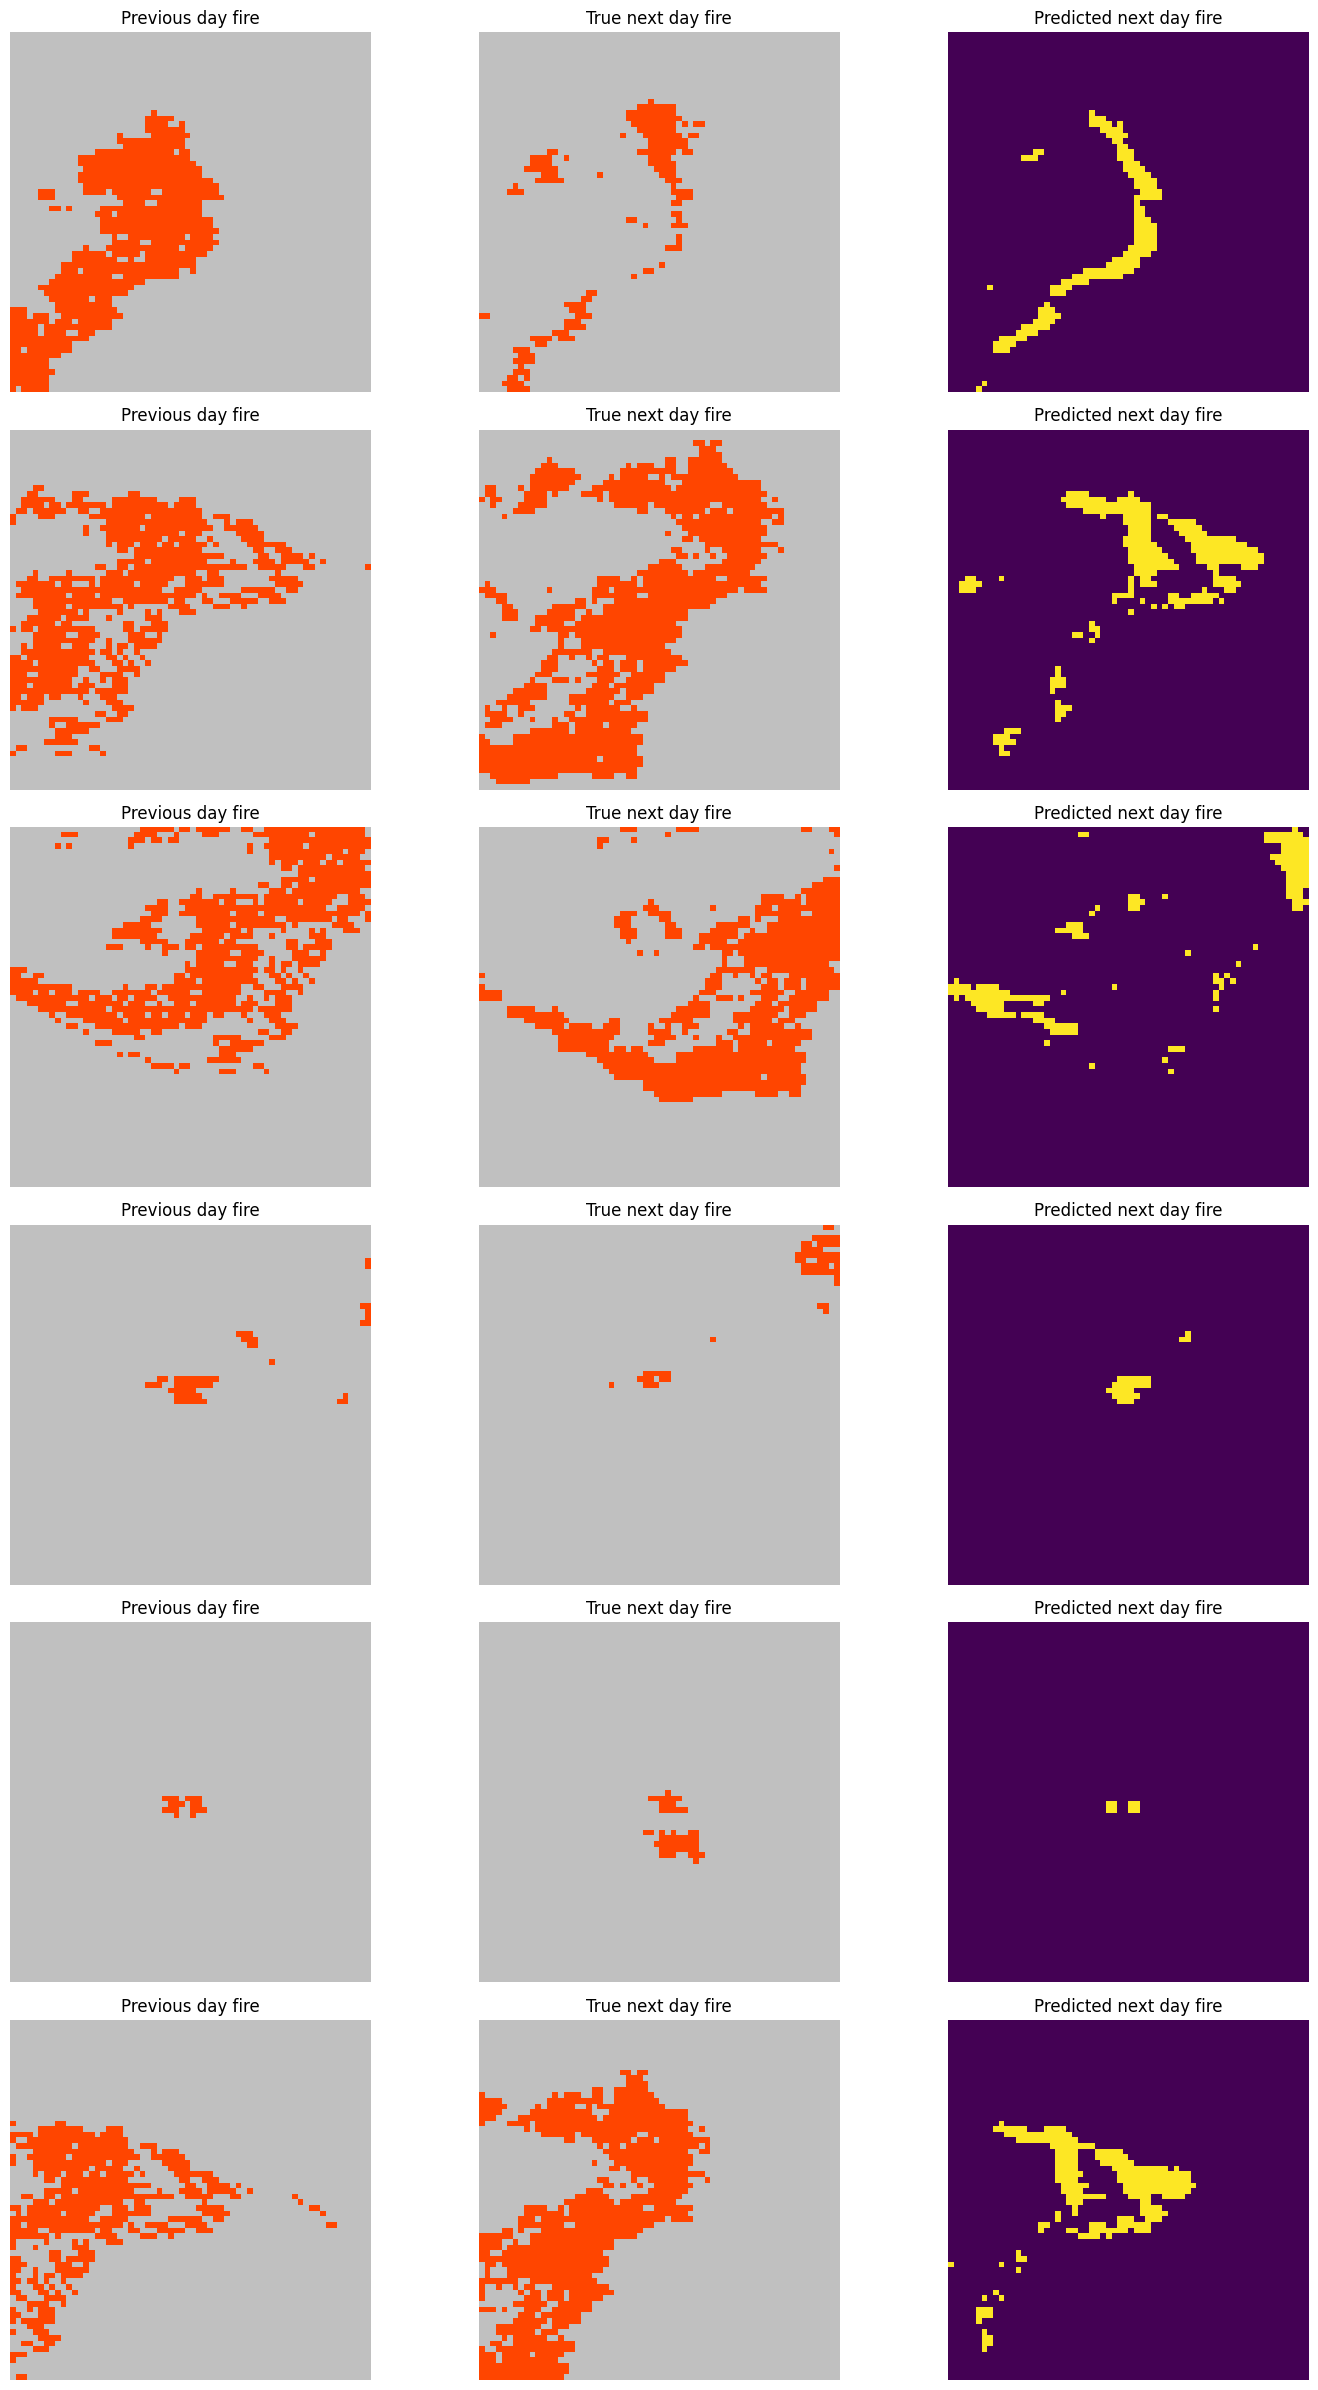

In [22]:
features, labels = next(iter(test_dataset))
show_inference(6, features, labels, lambda x: tf.where(unet_model.predict(x) > 0.5, 1, 0)[:,:,:,0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


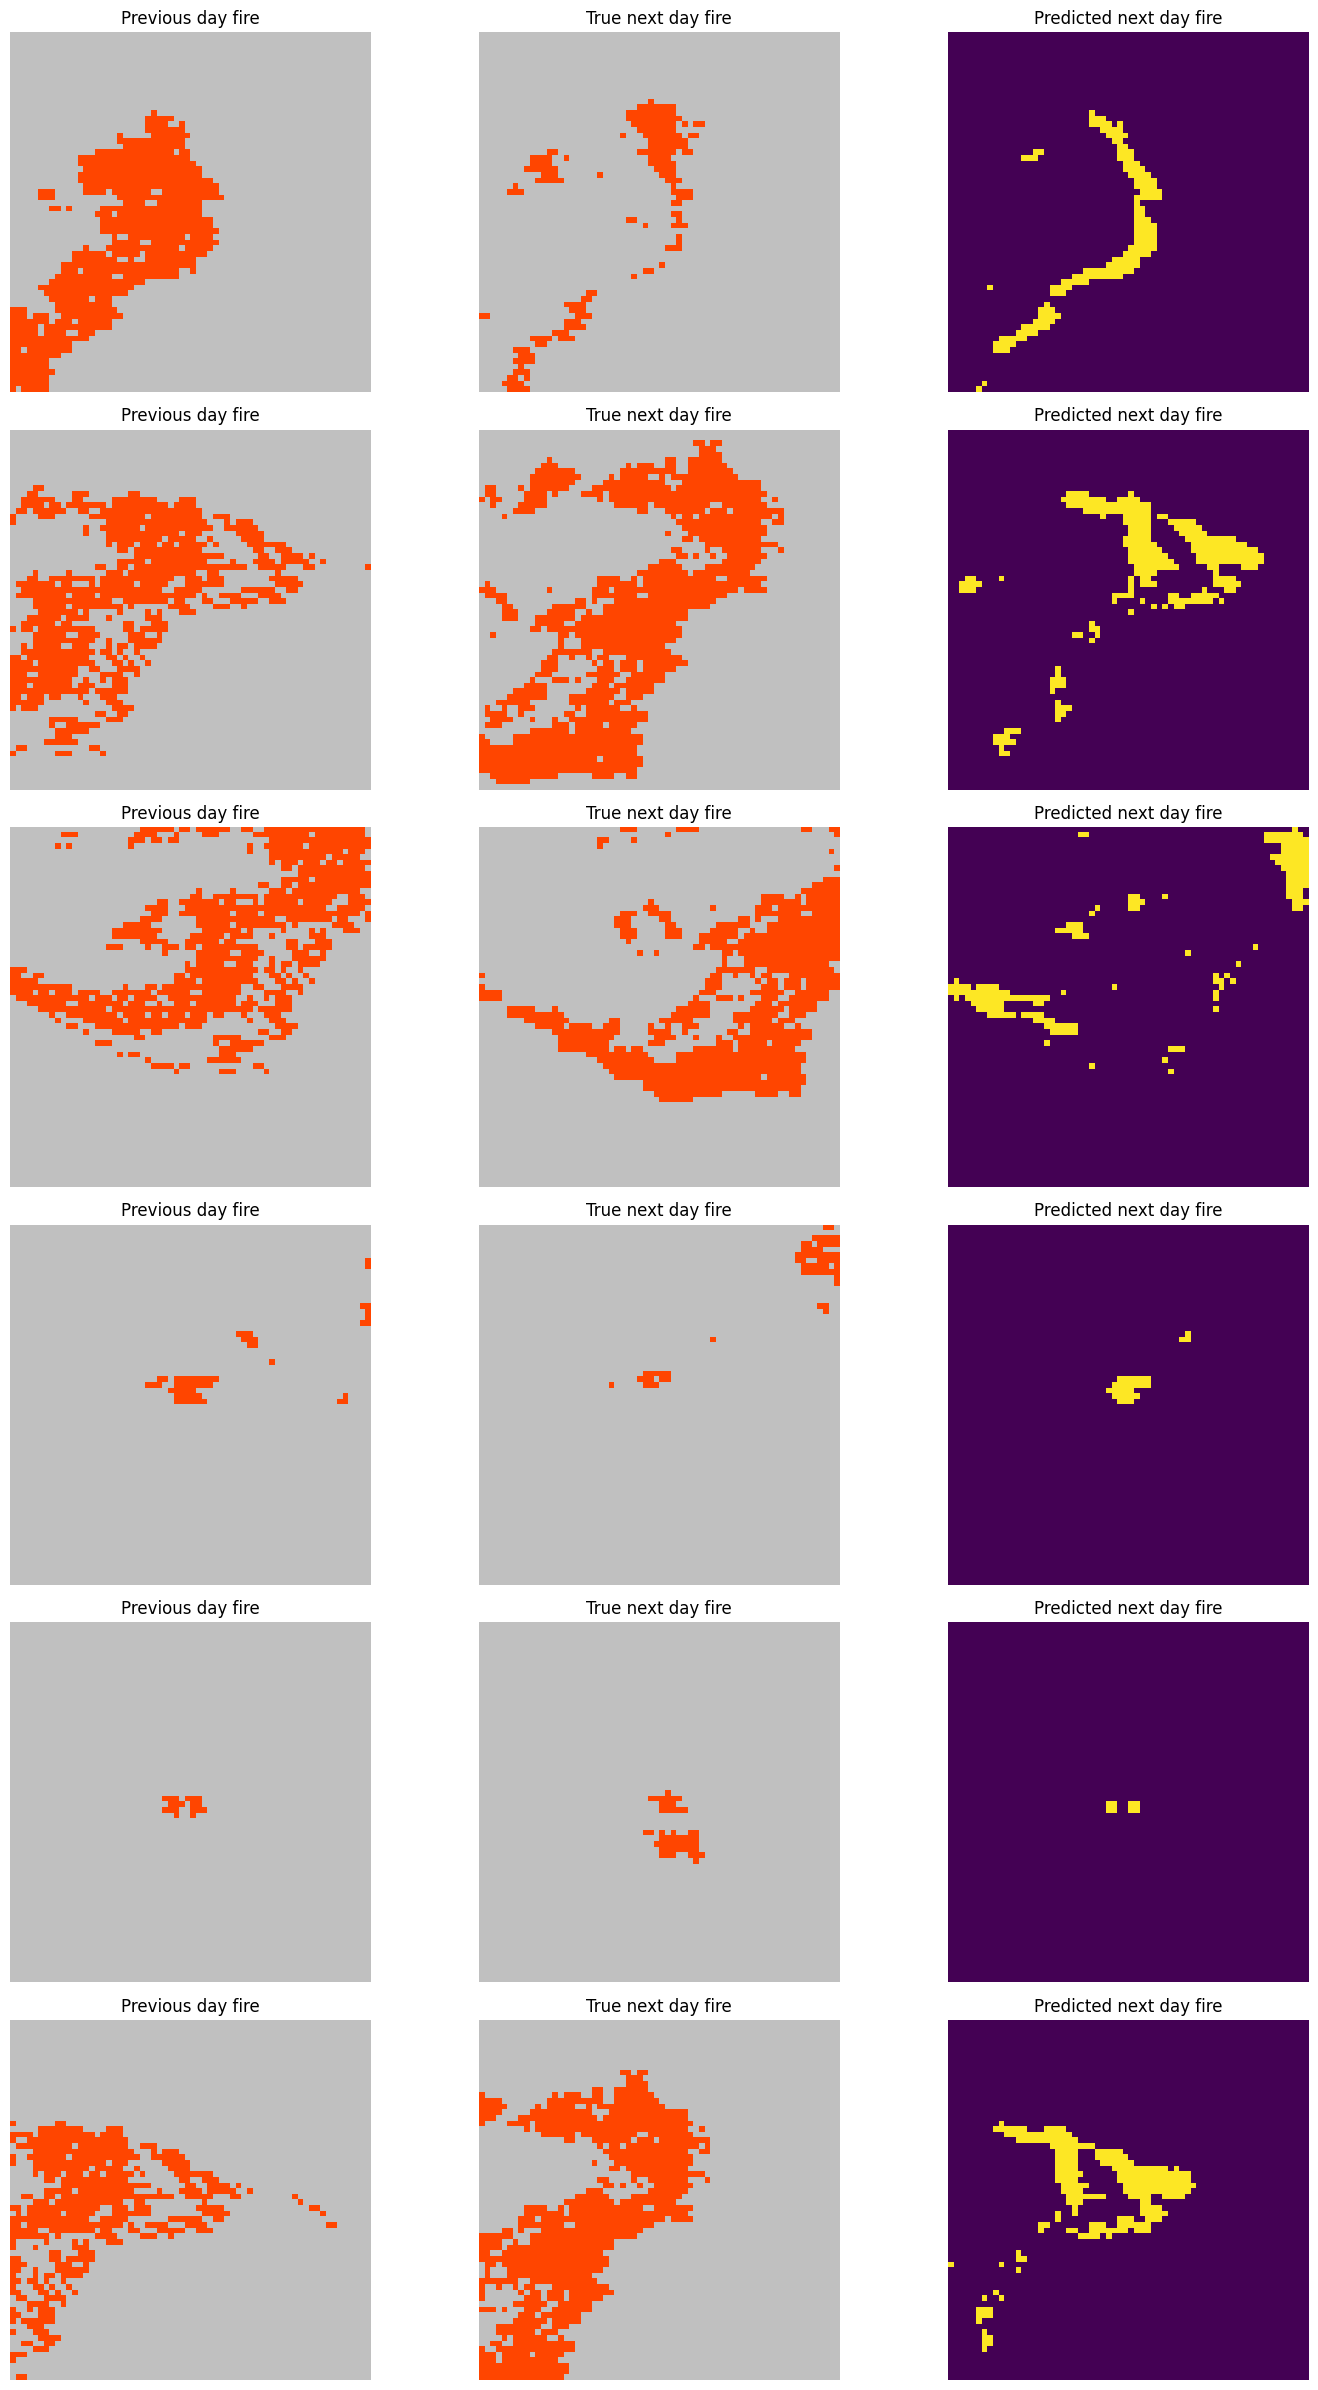

In [23]:
features, labels = next(iter(test_dataset))
show_inference(6, features, labels, lambda x: tf.where(unet_model.predict(x) > 0.5, 1, 0)[:,:,:,0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


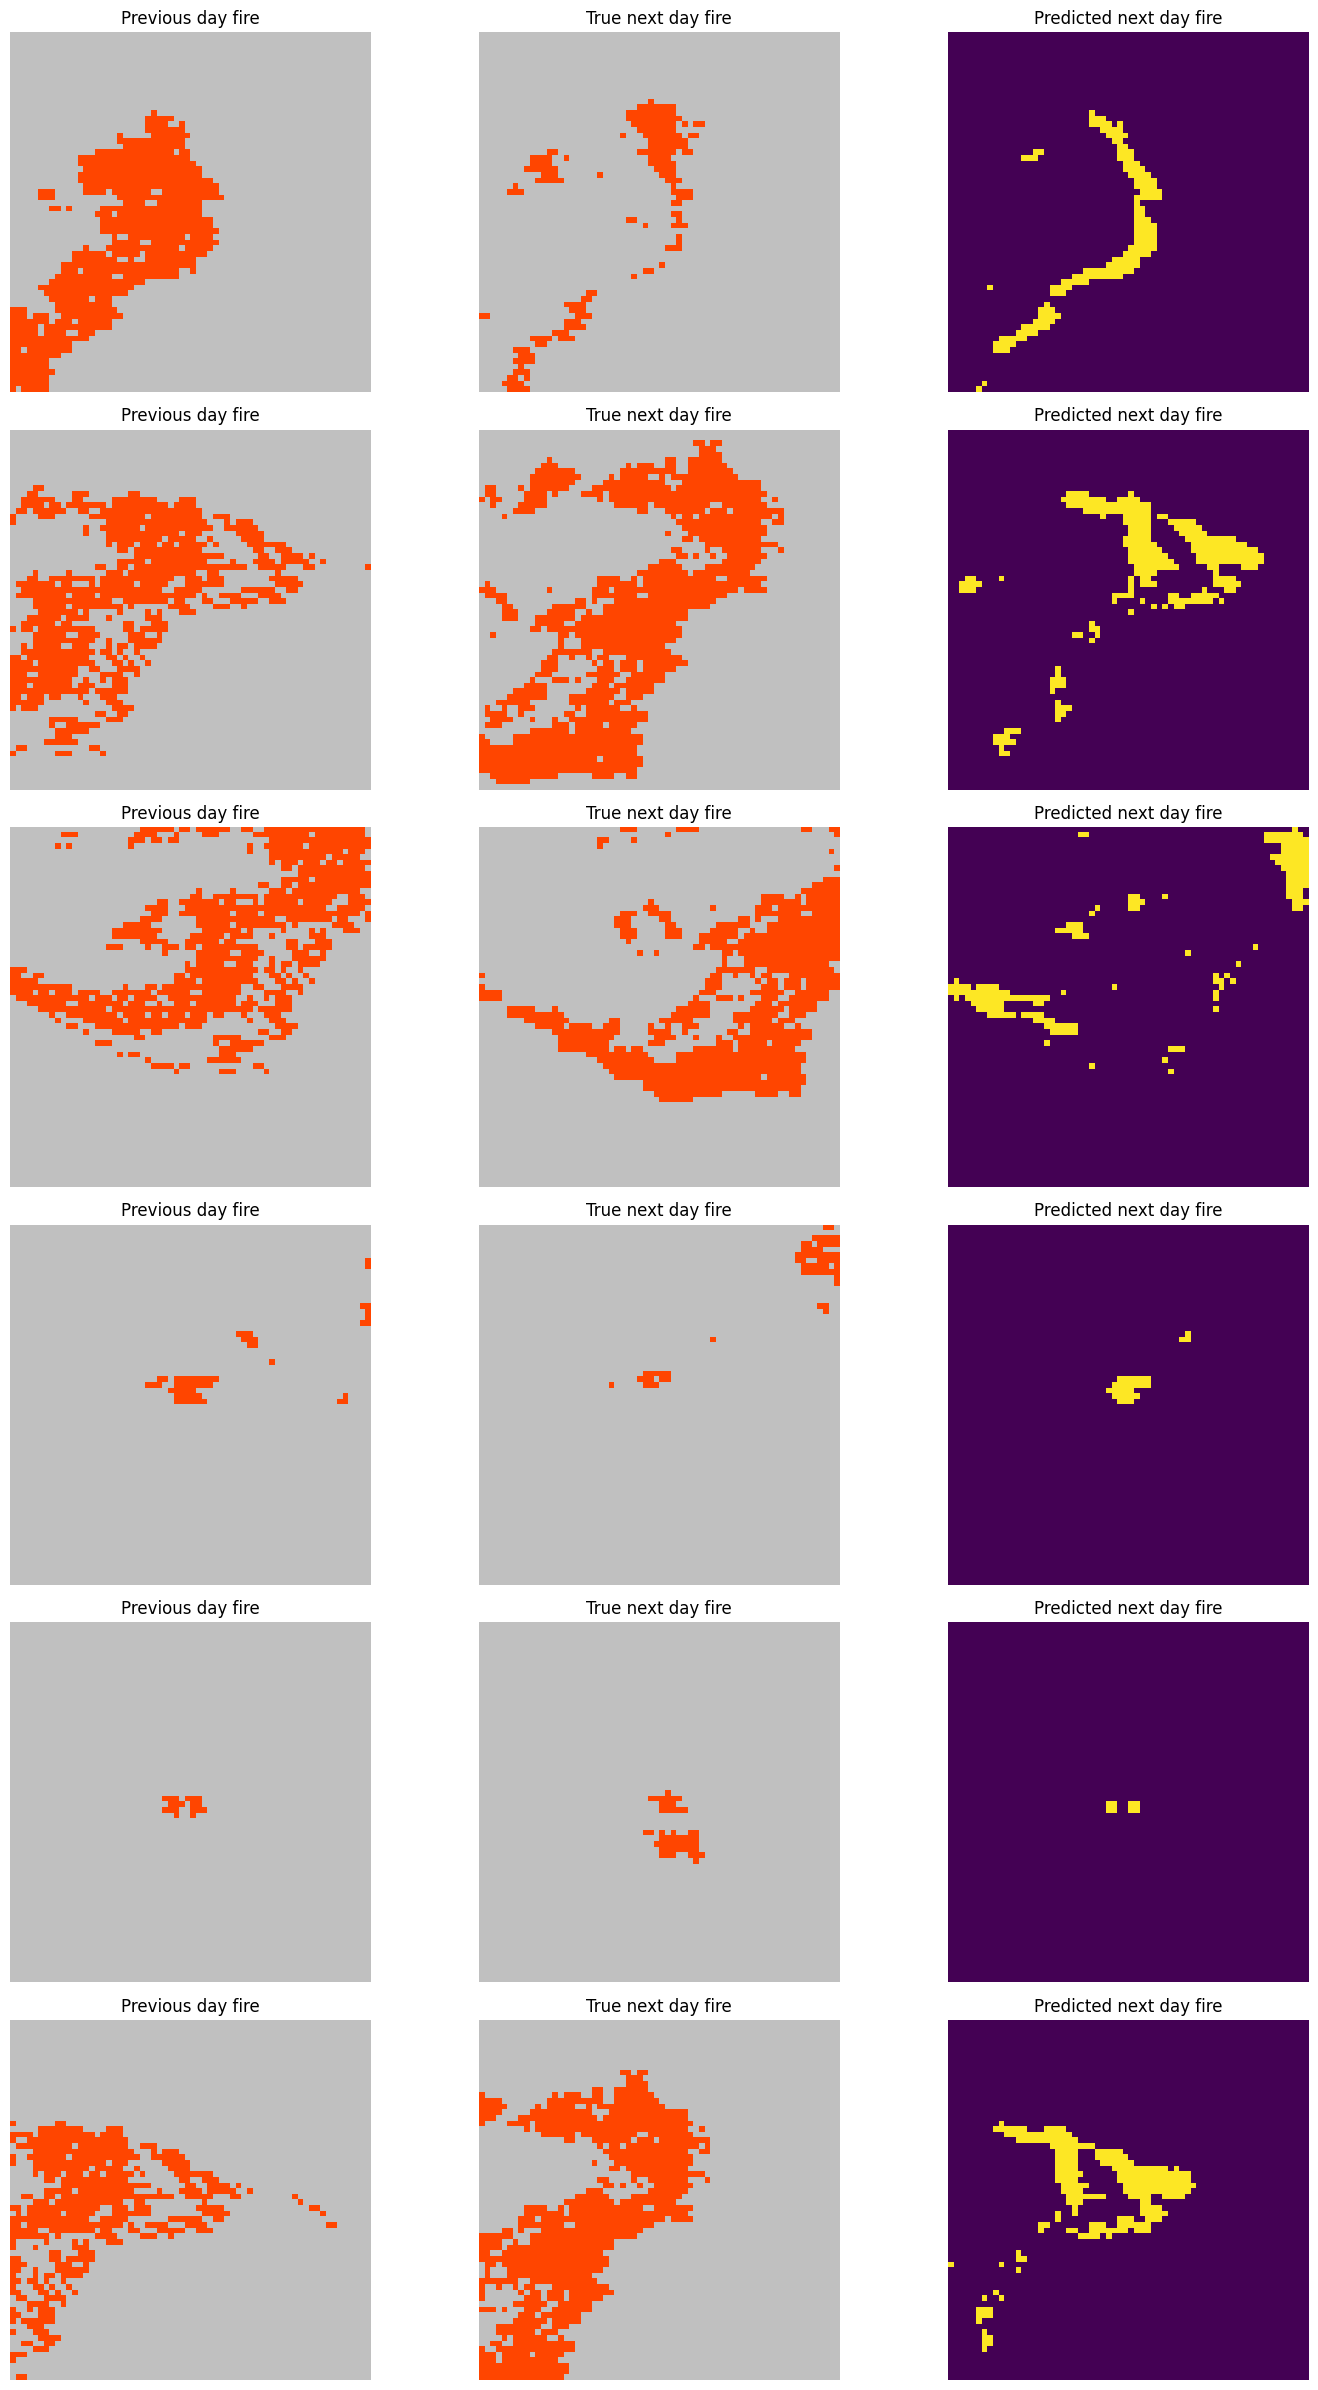

In [24]:
features, labels = next(iter(test_dataset))
show_inference(6, features, labels, lambda x: tf.where(unet_model.predict(x) > 0.5, 1, 0)[:,:,:,0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


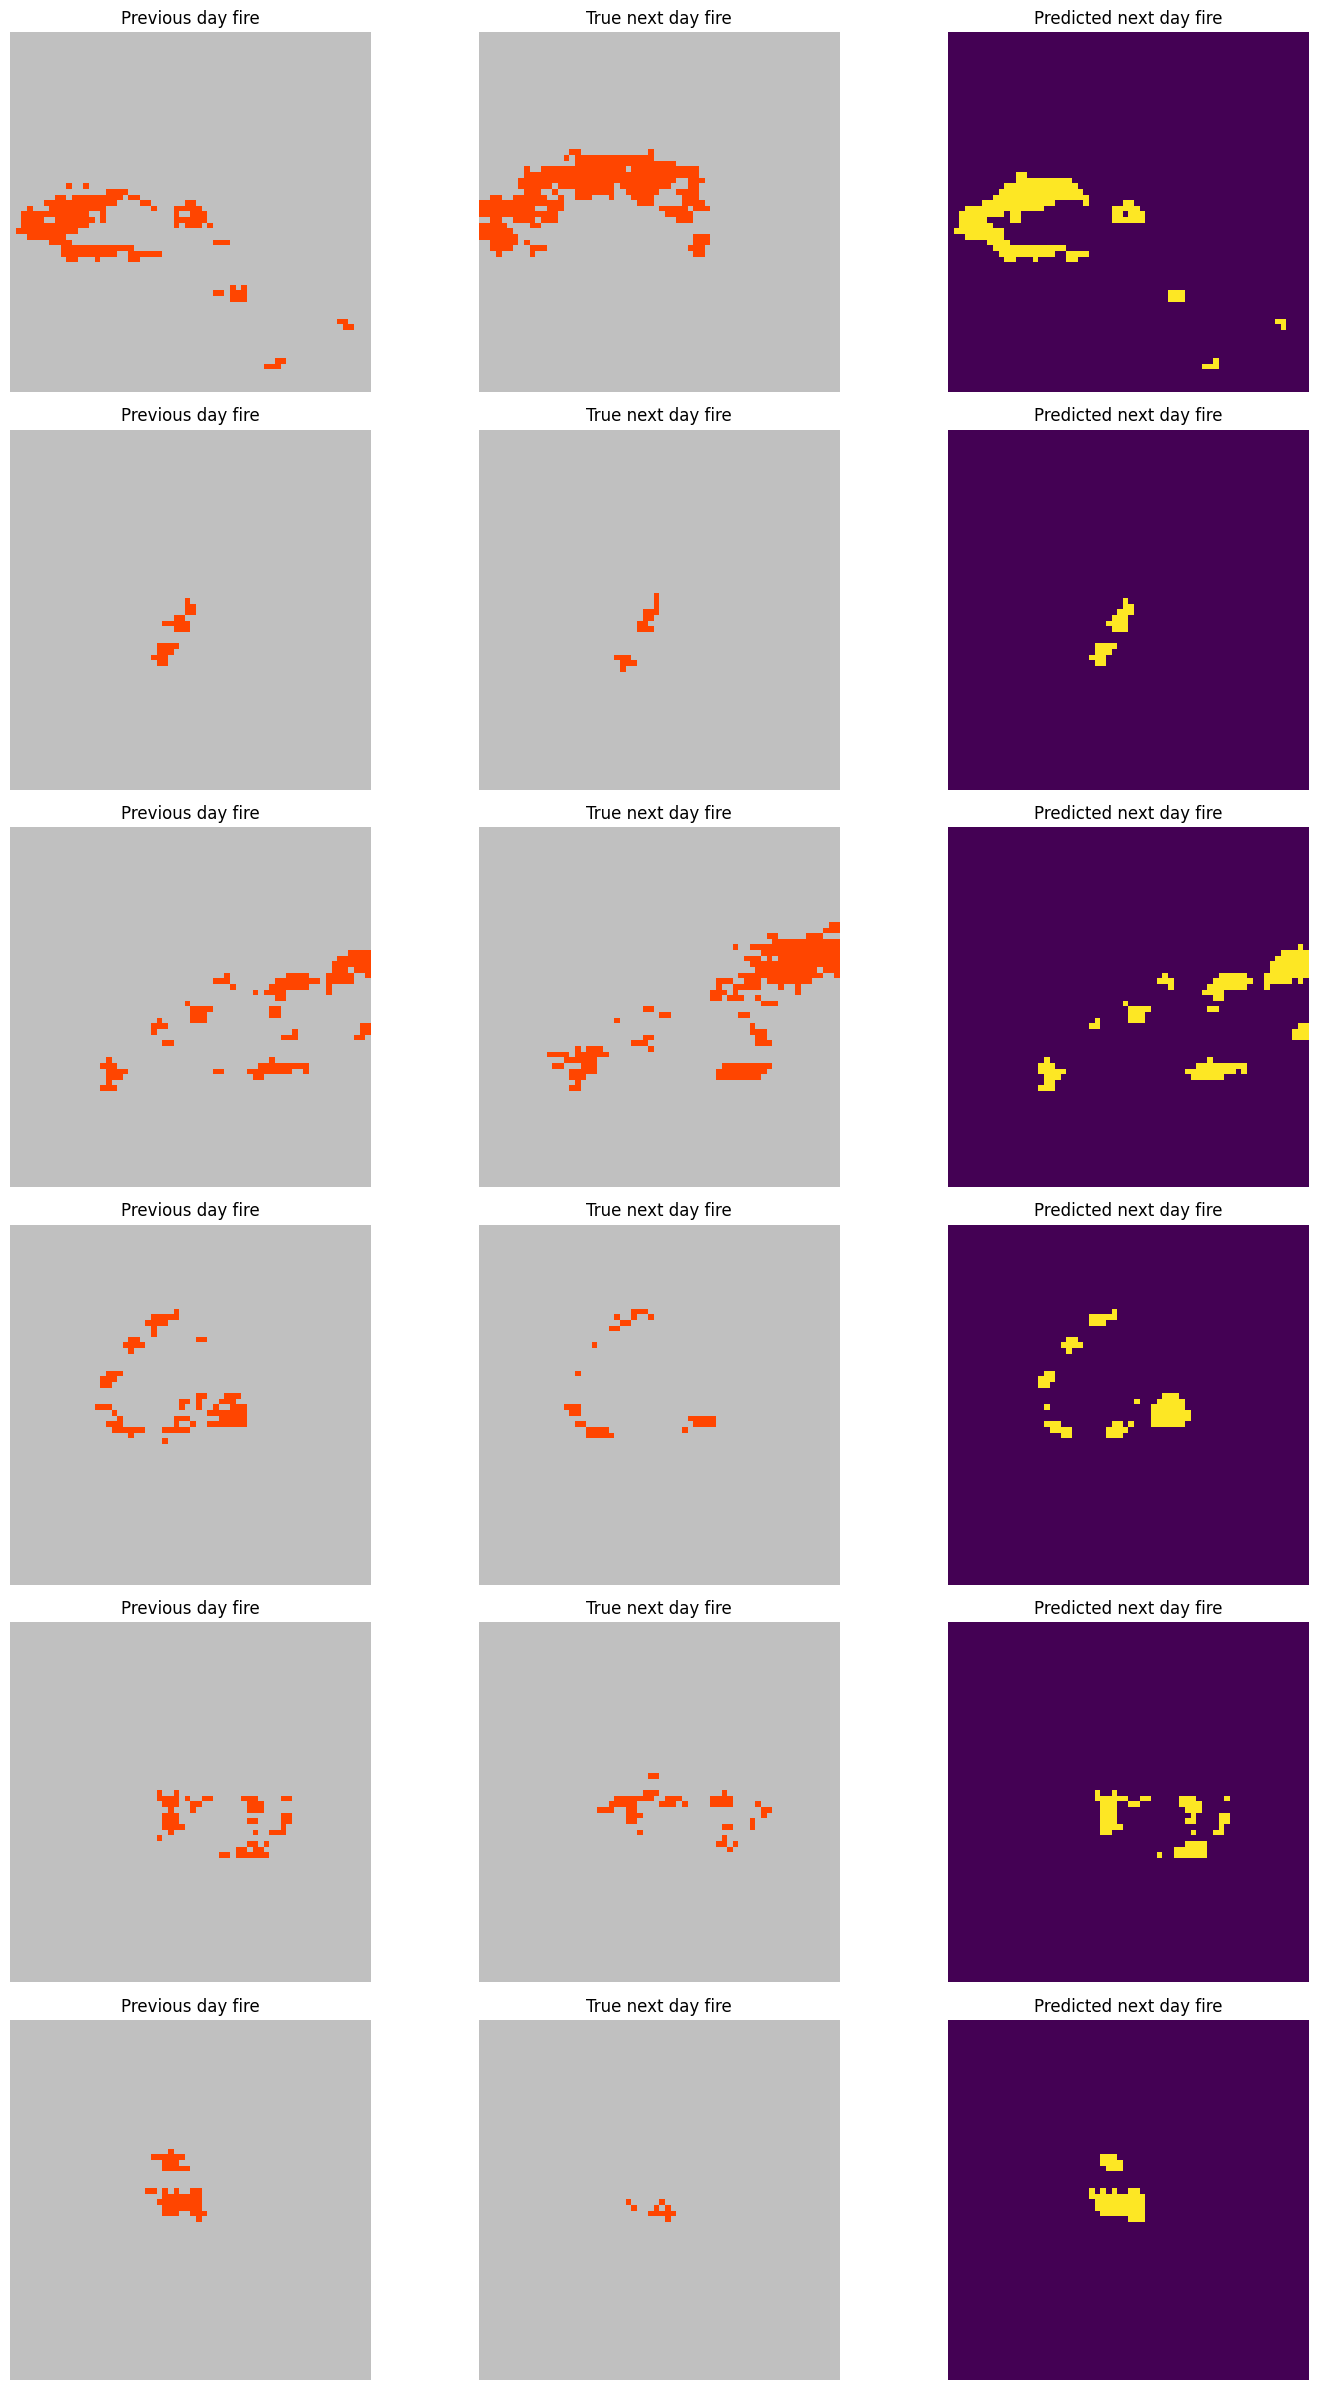

In [25]:
import random

samples = list(test_dataset.unbatch().take(500))   # take subset
batch = random.sample(samples, 6)

features = tf.stack([x[0] for x in batch])
labels   = tf.stack([x[1] for x in batch])

pred_probs = unet_model.predict(features)

show_inference(
    6,
    features,
    labels,
    lambda x: (pred_probs > 0.35).astype(int)[:,:,:,0]
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


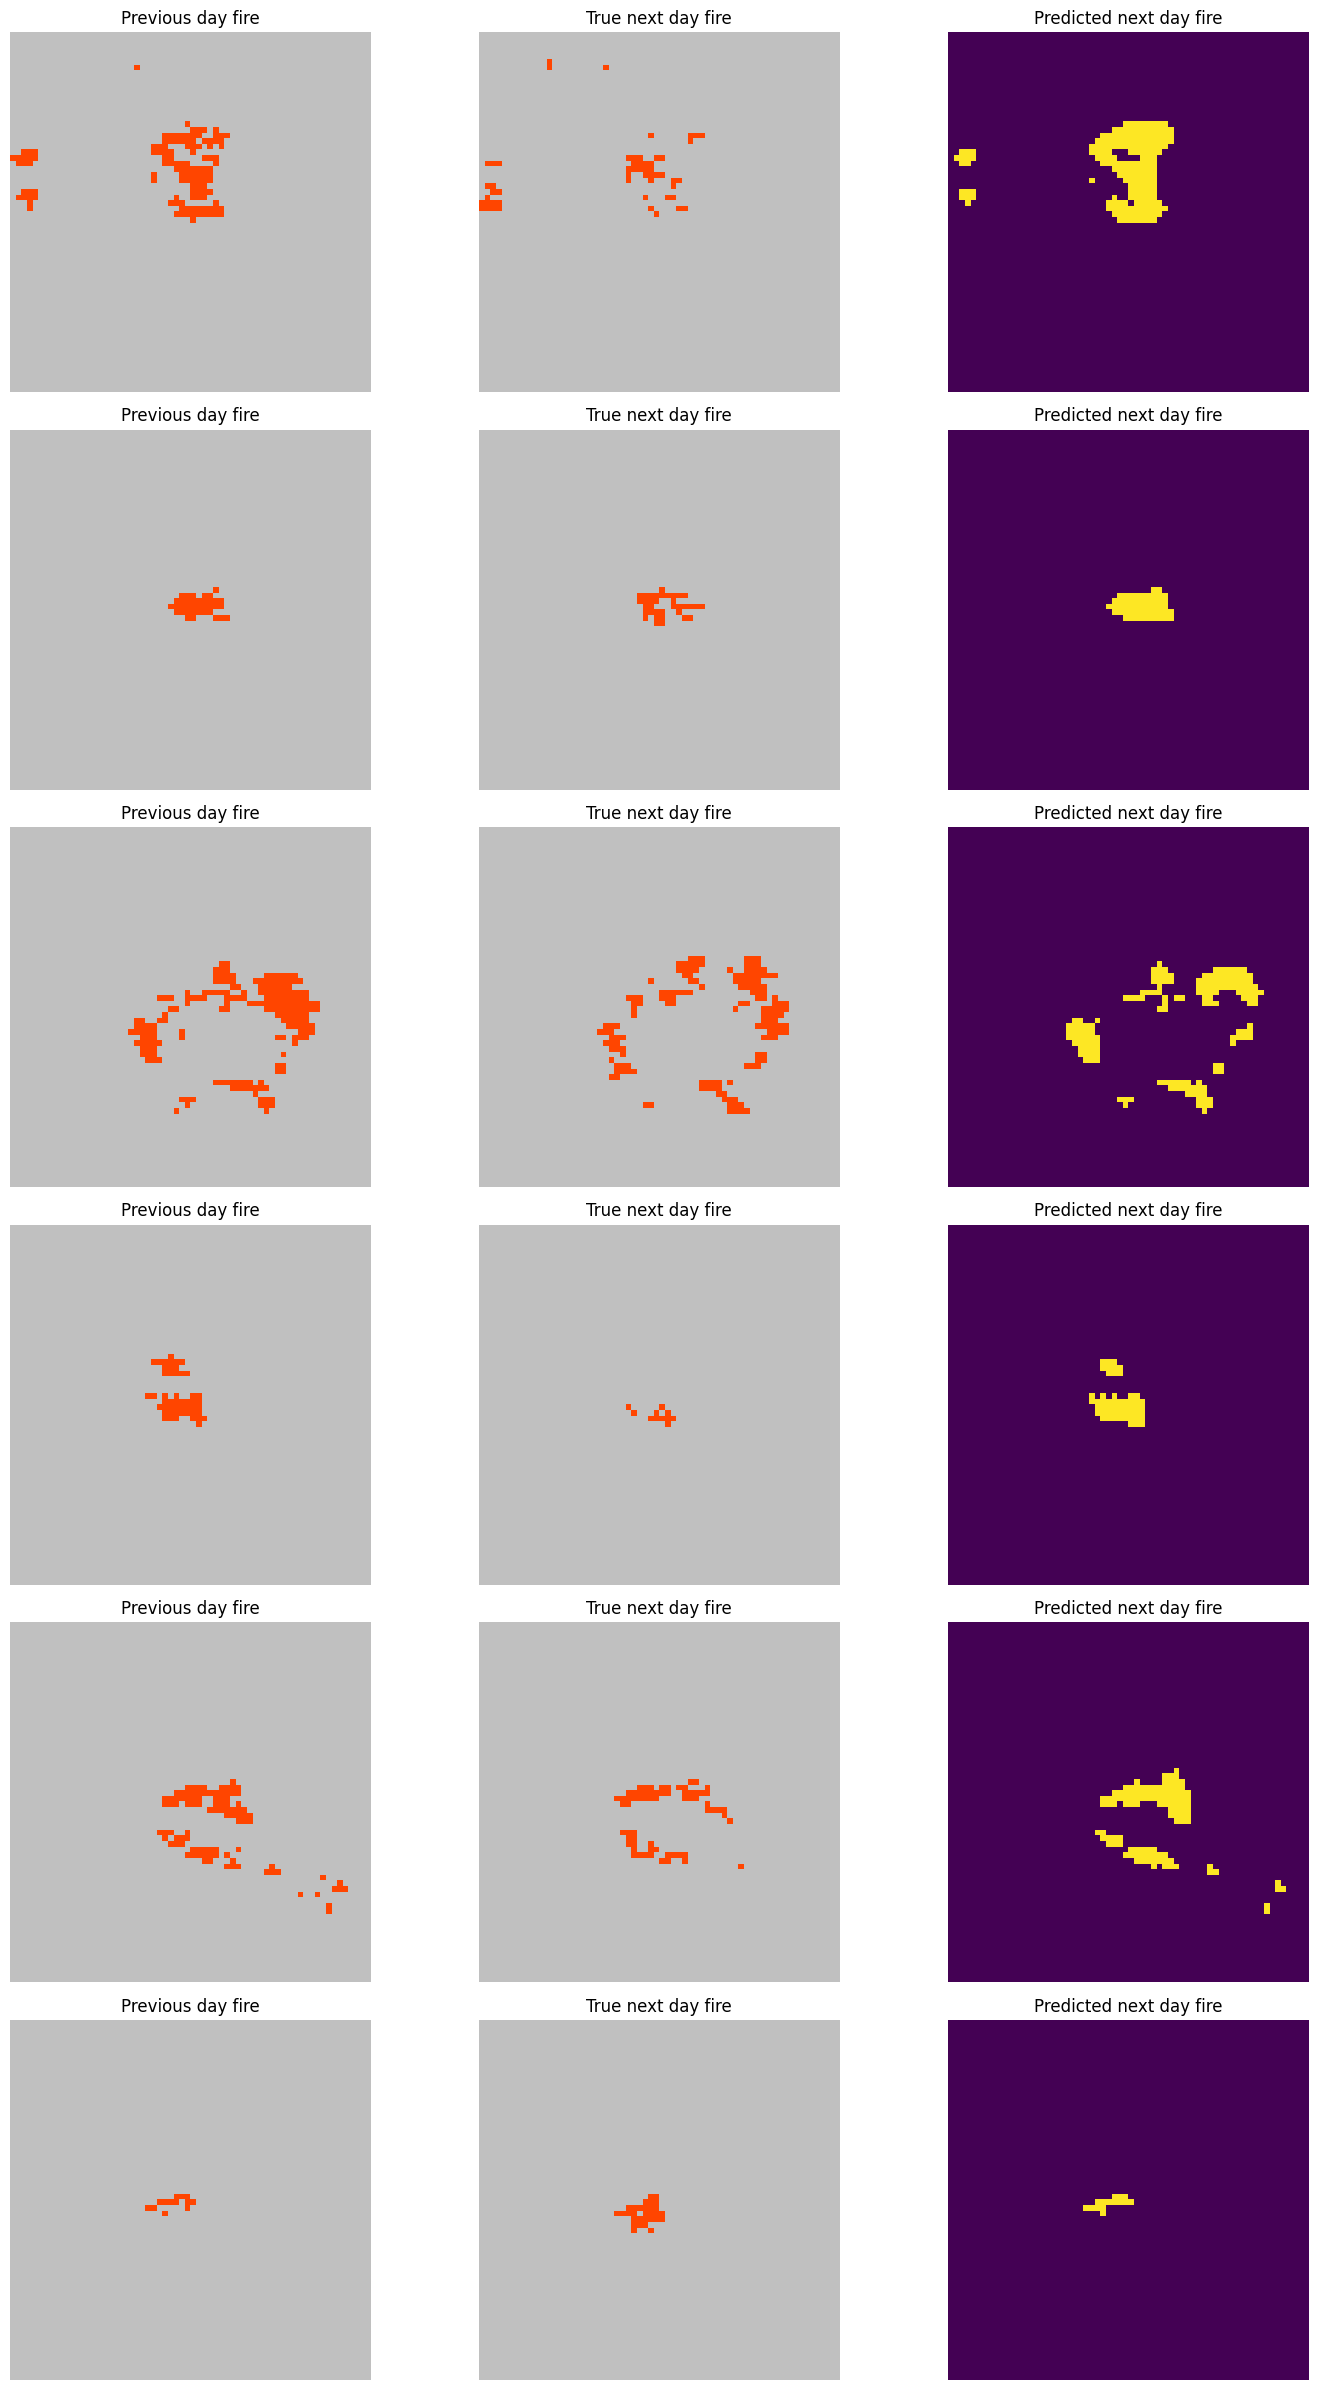

In [26]:
import random

samples = list(test_dataset.unbatch().take(500))   # take subset
batch = random.sample(samples, 6)

features = tf.stack([x[0] for x in batch])
labels   = tf.stack([x[1] for x in batch])

pred_probs = unet_model.predict(features)

show_inference(
    6,
    features,
    labels,
    lambda x: (pred_probs > 0.35).astype(int)[:,:,:,0]
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


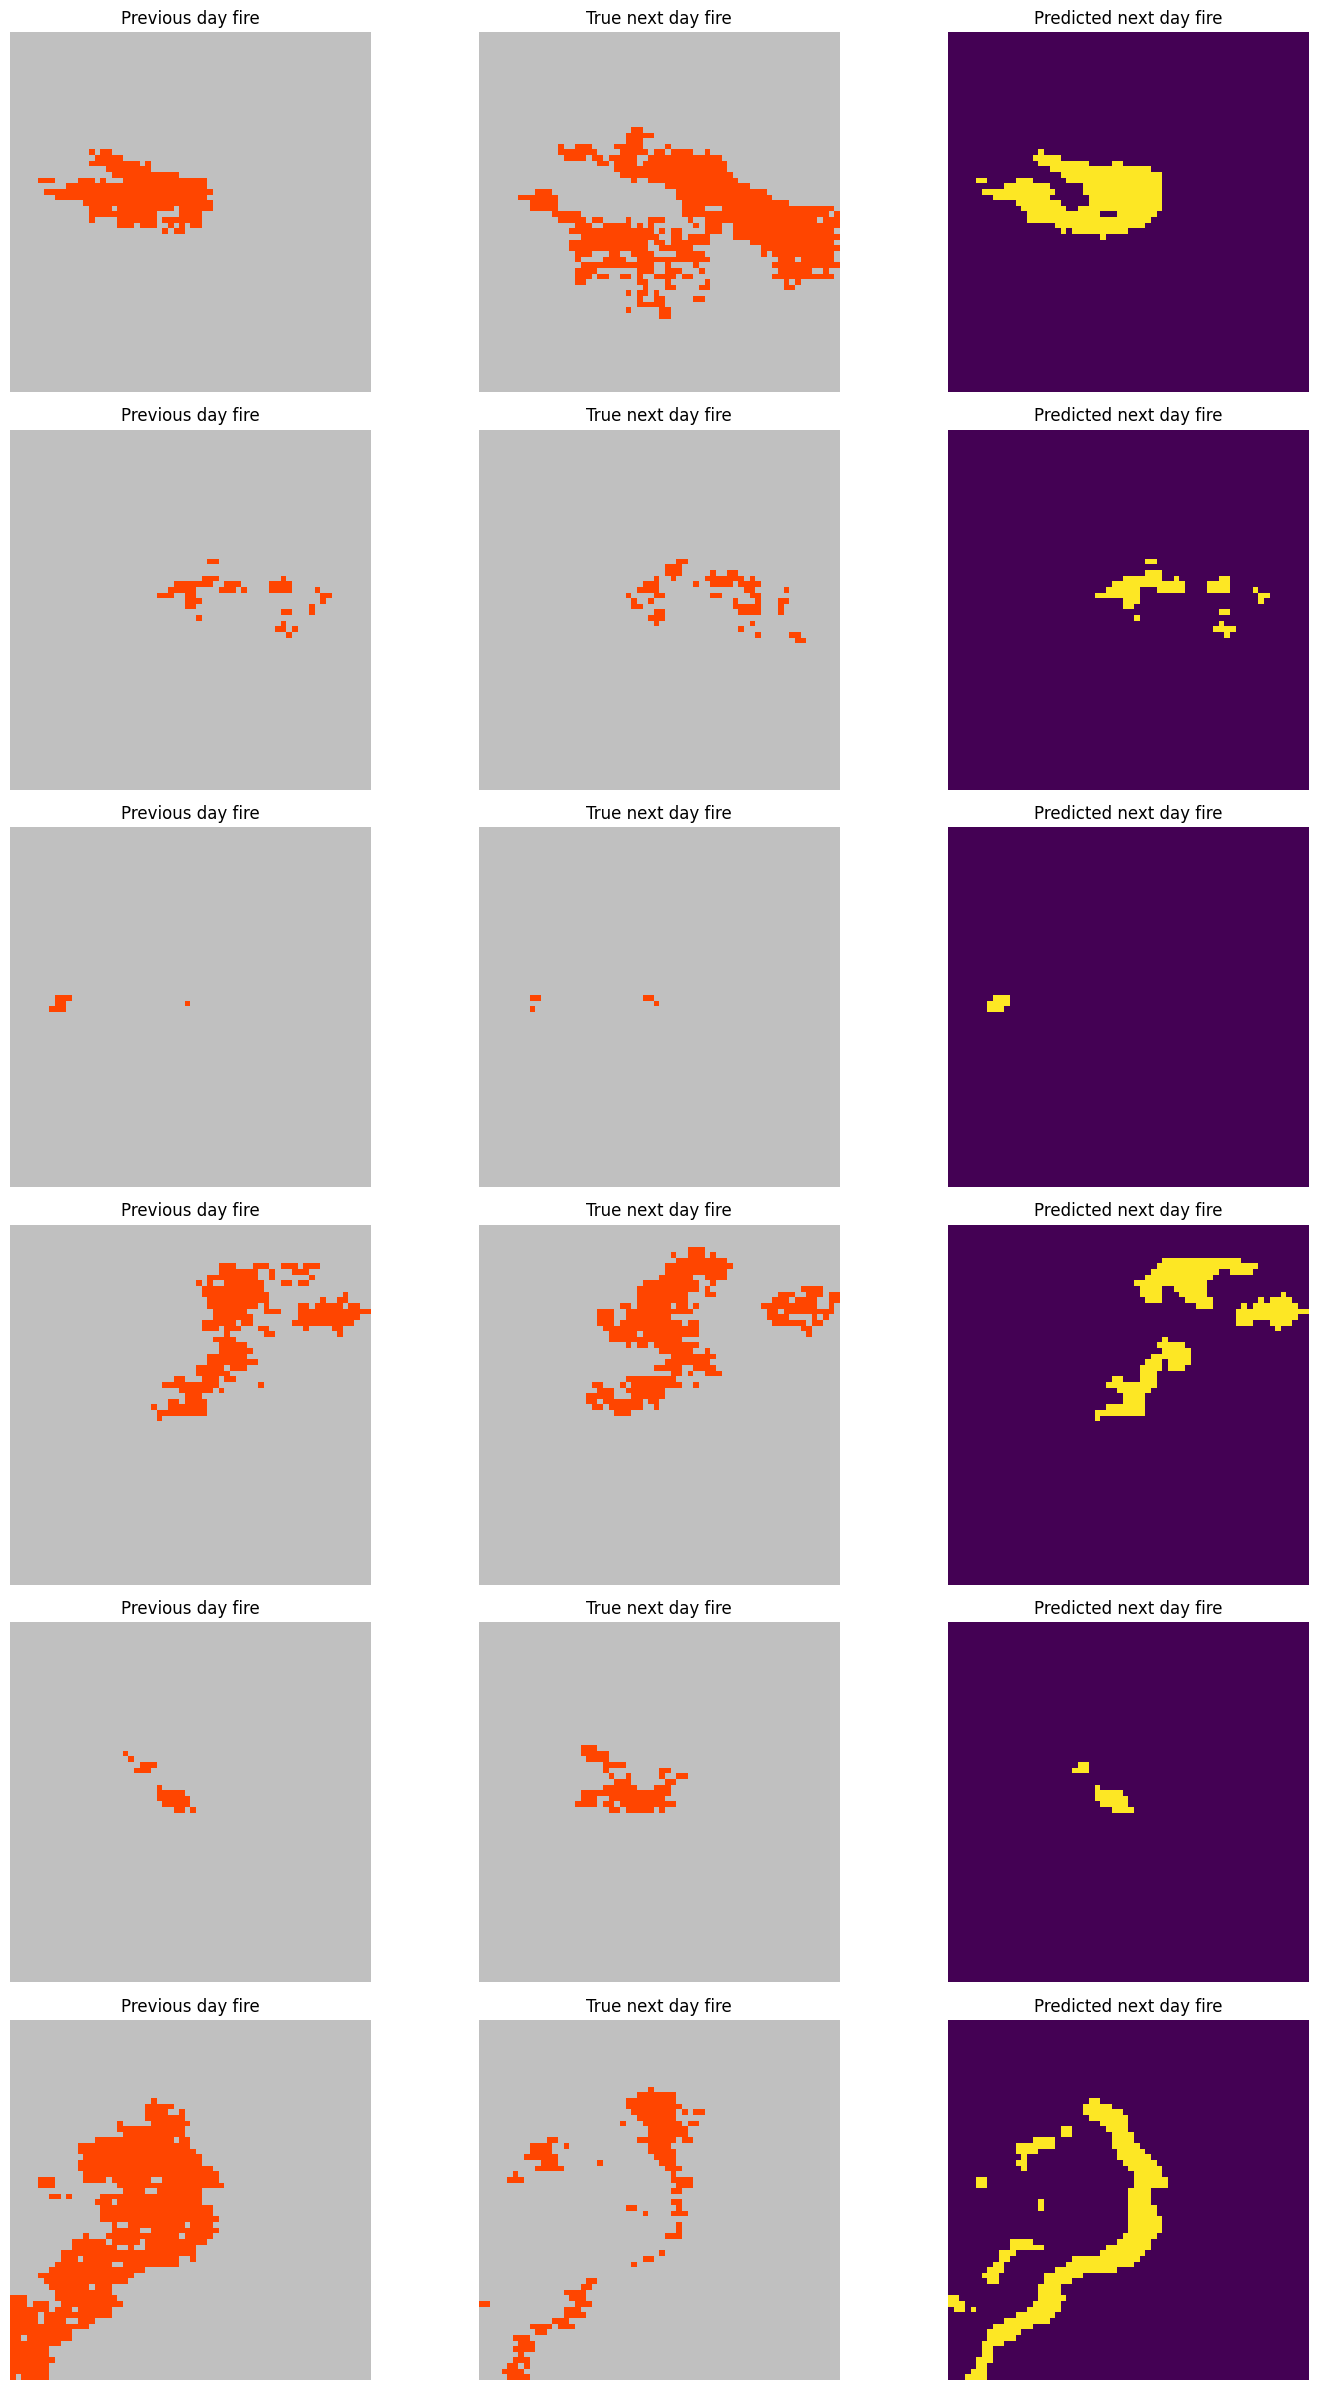

In [27]:
import random

samples = list(test_dataset.unbatch().take(500))   # take subset
batch = random.sample(samples, 6)

features = tf.stack([x[0] for x in batch])
labels   = tf.stack([x[1] for x in batch])

pred_probs = unet_model.predict(features)

show_inference(
    6,
    features,
    labels,
    lambda x: (pred_probs > 0.35).astype(int)[:,:,:,0]
)


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#  Research-Grade Metrics & Visualisation — U-Net Baseline
#  All charts use the recorded training history + final test results.
#  Run this cell AFTER training is complete (history object must exist),
#  OR run as-is — history values are hardcoded from the saved run.
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

# ── Recorded training history (hardcoded from saved run) ─────────────────────
# Replace with:  history_data = history.history  if running live
history_data = {
    'loss':                [0.1785, 0.095, 0.0927, 0.0853, 0.0822, 0.0782, 0.0787, 0.0767, 0.0737, 0.0708],
    'IoU_score':           [0.0455, 0.0453, 0.0653, 0.0905, 0.109, 0.1269, 0.1386, 0.1591, 0.1759, 0.2062],
    'dice_coefficient':    [0.0817, 0.0819, 0.1163, 0.1598, 0.1912, 0.2208, 0.239, 0.27, 0.294, 0.3362],
    'recall':              [0.0531, 0.0337, 0.0566, 0.0849, 0.1126, 0.1305, 0.1458, 0.1686, 0.195, 0.2326],
    'precision':           [0.2861, 0.5162, 0.5193, 0.5369, 0.5476, 0.5599, 0.5719, 0.5831, 0.5981, 0.6147],
    'val_loss':            [0.0851, 0.0831, 0.0821, 0.0884, 0.0788, 0.0829, 0.079, 0.0803, 0.0809, 0.0812],
    'val_IoU_score':       [0.0, 0.1137, 0.0, 0.1771, 0.1631, 0.0662, 0.1147, 0.209, 0.1121, 0.1699],
    'val_dice_coefficient':[0.0, 0.2043, 0.0, 0.3009, 0.2805, 0.1243, 0.2057, 0.3458, 0.2016, 0.2904],
    'val_recall':          [0.000189, 0.1628, 0.000375, 0.2052, 0.1846, 0.0749, 0.1274, 0.3049, 0.1171, 0.1784],
    'val_precision':       [0.8195, 0.5201, 0.7552, 0.5026, 0.5375, 0.5925, 0.5244, 0.4892, 0.5896, 0.5218],
    'learning_rate':       [0.001, 0.001, 0.001, 0.0007, 0.00049, 0.00049, 0.00049, 0.000343, 0.000343, 0.00024],
}

epochs      = list(range(1, len(history_data['loss']) + 1))
best_epoch  = 8

# ── Final test-set results ────────────────────────────────────────────────────
test_iou       = 0.484
test_recall    = 0.2769
test_precision = 0.4339
test_f1        = 2 * test_precision * test_recall / (test_precision + test_recall + 1e-9)
test_dice      = test_f1

# ── Colour palette (consistent across all plots) ─────────────────────────────
C_TRAIN = '#E05A2B'   # warm orange-red  — train
C_VAL   = '#2B6CB0'   # deep blue        — validation
C_BEST  = '#2D9E5C'   # green            — best epoch marker
C_GRID  = '#E8E8E8'
FONT    = {'family': 'DejaVu Sans'}
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : C_GRID,
    'grid.linewidth'   : 0.6,
    'figure.dpi'       : 150,
})

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 1 — Training curves  (2 × 2 grid)
# ════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 2, figsize=(13, 9))
fig1.suptitle('U-Net Baseline — Training & Validation Curves',
              fontsize=15, fontweight='bold', y=1.01)

metrics = [
    ('loss',             'val_loss',             'Loss (Dice-BCE)',    True),
    ('IoU_score',        'val_IoU_score',        'IoU Score',         False),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient',  False),
    ('recall',           'val_recall',           'Recall',            False),
]

for ax, (tr_key, val_key, title, is_loss) in zip(axes.flat, metrics):
    tr  = history_data[tr_key]
    val = history_data[val_key]

    ax.plot(epochs, tr,  color=C_TRAIN, lw=2,   label='Train',      marker='o', ms=4)
    ax.plot(epochs, val, color=C_VAL,   lw=2,   label='Validation', marker='s', ms=4, linestyle='--')
    ax.axvline(best_epoch, color=C_BEST, lw=1.2, linestyle=':', label=f'Best epoch ({best_epoch})')

    best_val = val[best_epoch - 1]
    ax.scatter(best_epoch, best_val, color=C_BEST, zorder=5, s=60)
    ax.annotate(f'{best_val:.3f}',
                xy=(best_epoch, best_val),
                xytext=(best_epoch + 0.3, best_val),
                fontsize=8, color=C_BEST)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=9)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(fontsize=8, framealpha=0.4)

# Remove unused 4th subplot for precision (replace with LR schedule)
ax = axes[1, 1]
ax.plot(epochs, history_data['learning_rate'], color='#7B4FA6', lw=2, marker='D', ms=4)
ax.axvline(best_epoch, color=C_BEST, lw=1.2, linestyle=':')
ax.set_title('Learning Rate Schedule', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=9)
ax.set_ylabel('LR', fontsize=9)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))

plt.tight_layout()
plt.savefig('unet_baseline_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: unet_baseline_training_curves.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 2 — Test-set metric summary bar chart
# ════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(8, 5))

metric_names  = ['IoU\nScore', 'Dice\nCoefficient', 'Precision', 'Recall', 'F1\nScore']
metric_values = [test_iou, test_dice, test_precision, test_recall, test_f1]
bar_colors    = ['#E05A2B', '#2B6CB0', '#2D9E5C', '#C4953A', '#8B4FA6']

bars = ax.bar(metric_names, metric_values, color=bar_colors,
              width=0.55, edgecolor='white', linewidth=1.2, zorder=3)

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color=bar.get_facecolor())

ax.set_ylim(0, 0.75)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('U-Net Baseline — Test Set Performance', fontsize=13, fontweight='bold', pad=12)
ax.axhline(0.5, color='#999', lw=0.8, linestyle='--', label='0.5 reference')
ax.legend(fontsize=9, framealpha=0.4)
ax.set_yticks(np.arange(0, 0.76, 0.1))
ax.grid(axis='y', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('unet_baseline_test_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: unet_baseline_test_metrics.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 3 — Precision vs Recall trade-off across epochs
# ════════════════════════════════════════════════════════════════════════════
fig3, ax = plt.subplots(figsize=(7, 6))

prec_tr  = history_data['precision']
rec_tr   = history_data['recall']
prec_val = history_data['val_precision']
rec_val  = history_data['val_recall']

sc_tr = ax.scatter(rec_tr, prec_tr, c=epochs, cmap='Oranges',
                   s=70, zorder=4, edgecolors='#333', linewidths=0.4, label='Train')
sc_val = ax.scatter(rec_val, prec_val, c=epochs, cmap='Blues',
                    s=70, zorder=4, edgecolors='#333', linewidths=0.4,
                    marker='s', label='Validation')

# Annotate epoch numbers
for e, (r, p) in enumerate(zip(rec_tr, prec_tr), 1):
    ax.annotate(str(e), (r, p), fontsize=7, ha='center', va='center', color='white', fontweight='bold')
for e, (r, p) in enumerate(zip(rec_val, prec_val), 1):
    ax.annotate(str(e), (r, p), fontsize=7, ha='center', va='center', color='white', fontweight='bold')

# Mark test point
ax.scatter(test_recall, test_precision, marker='*', s=250, color='#E05A2B',
           zorder=6, label=f'Test (IoU={test_iou:.3f})', edgecolors='#333', linewidths=0.5)

# F1 iso-curves
for f1_val in [0.2, 0.3, 0.4, 0.5]:
    r_range = np.linspace(0.01, 0.99, 200)
    p_iso   = f1_val * r_range / (2 * r_range - f1_val + 1e-9)
    mask    = (p_iso >= 0) & (p_iso <= 1)
    ax.plot(r_range[mask], p_iso[mask], color='#CCC', lw=0.8, linestyle=':')
    idx = np.argmin(np.abs(r_range - 0.6))
    if mask[idx]:
        ax.text(r_range[idx], p_iso[idx] + 0.02, f'F1={f1_val}',
                fontsize=7, color='#999', ha='center')

ax.set_xlim(0, 0.8); ax.set_ylim(0, 1.0)
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision–Recall Trade-off Across Epochs\nU-Net Baseline', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', framealpha=0.6)

plt.tight_layout()
plt.savefig('unet_baseline_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: unet_baseline_precision_recall.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 4 — Radar / spider chart of test metrics
# ════════════════════════════════════════════════════════════════════════════
from matplotlib.patches import FancyArrowPatch

categories   = ['IoU', 'Dice', 'Precision', 'Recall', 'F1']
values       = [test_iou, test_dice, test_precision, test_recall, test_f1]
N            = len(categories)
angles       = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
values_plot  = values + [values[0]]
angles_plot  = angles + [angles[0]]
labels_plot  = categories + [categories[0]]

fig4, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles_plot,  values_plot, color=C_TRAIN, lw=2, marker='o', ms=6)
ax.fill(angles_plot,  values_plot, color=C_TRAIN, alpha=0.18)

# Reference circle at 0.5
ref = [0.5] * (N + 1)
ax.plot(angles_plot, ref, color='#AAA', lw=0.8, linestyle='--')

ax.set_xticks(angles)
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=8, color='#666')
ax.set_title('U-Net Baseline\nTest Set — Metric Radar',
             fontsize=13, fontweight='bold', pad=20)

# Annotate values on spokes
for angle, val, cat in zip(angles, values, categories):
    ax.text(angle, val + 0.07, f'{val:.3f}',
            ha='center', va='center', fontsize=9,
            color=C_TRAIN, fontweight='bold')

plt.tight_layout()
plt.savefig('unet_baseline_radar.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: unet_baseline_radar.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 5 — Train vs Val IoU & Dice side-by-side (epoch-level summary)
# ════════════════════════════════════════════════════════════════════════════
fig5, axes5 = plt.subplots(1, 2, figsize=(13, 5))
fig5.suptitle('U-Net Baseline — IoU & Dice: Train vs Validation per Epoch',
              fontsize=13, fontweight='bold')

pairs = [
    ('IoU_score',        'val_IoU_score',        'IoU Score',        axes5[0]),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient', axes5[1]),
]

for tr_key, val_key, title, ax in pairs:
    x      = np.arange(len(epochs))
    width  = 0.35
    tr_v   = history_data[tr_key]
    val_v  = history_data[val_key]

    b1 = ax.bar(x - width/2, tr_v,  width, label='Train',      color=C_TRAIN, alpha=0.85, edgecolor='white')
    b2 = ax.bar(x + width/2, val_v, width, label='Validation', color=C_VAL,   alpha=0.85, edgecolor='white')

    ax.axvline(best_epoch - 1, color=C_BEST, lw=1.2, linestyle=':', label=f'Best epoch ({best_epoch})')
    ax.set_xticks(x)
    ax.set_xticklabels([f'E{e}' for e in epochs], fontsize=8)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.4)
    ax.set_ylim(0, 0.55)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('unet_baseline_epoch_bars.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: unet_baseline_epoch_bars.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 6 — Summary metrics table (publication-ready)
# ════════════════════════════════════════════════════════════════════════════
fig6, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table_data = [
    ['Metric',        'Train (final epoch)', 'Validation (best)',  'Test Set'],
    ['IoU Score',
        f'{history_data["IoU_score"][-1]:.4f}',
        f'{max(history_data["val_IoU_score"]):.4f}',
        f'{test_iou:.4f}'],
    ['Dice Coefficient',
        f'{history_data["dice_coefficient"][-1]:.4f}',
        f'{max(history_data["val_dice_coefficient"]):.4f}',
        f'{test_dice:.4f}'],
    ['Precision',
        f'{history_data["precision"][-1]:.4f}',
        f'{history_data["val_precision"][best_epoch-1]:.4f}',
        f'{test_precision:.4f}'],
    ['Recall',
        f'{history_data["recall"][-1]:.4f}',
        f'{history_data["val_recall"][best_epoch-1]:.4f}',
        f'{test_recall:.4f}'],
    ['F1 Score',       '—',                 '—',                  f'{test_f1:.4f}'],
]

tbl = ax.table(cellText=table_data[1:],
               colLabels=table_data[0],
               cellLoc='center', loc='center',
               bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

# Style header
for j in range(4):
    tbl[0, j].set_facecolor('#2B3A55')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Style alternating rows + highlight test column
for i in range(1, len(table_data)):
    for j in range(4):
        cell = tbl[i, j]
        cell.set_facecolor('#F5F5F5' if i % 2 == 0 else 'white')
        if j == 3:   # test column
            cell.set_facecolor('#FFF3E0')
            cell.set_text_props(fontweight='bold', color='#B83C12')

tbl.auto_set_column_width([0, 1, 2, 3])
ax.set_title('U-Net Baseline — Complete Metrics Summary',
             fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('unet_baseline_metrics_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: unet_baseline_metrics_table.png")

print("\n" + "="*55)
print("  U-Net Baseline — All figures saved successfully")
print("="*55)
print(f"  IoU       : {test_iou:.4f}")
print(f"  Dice      : {test_dice:.4f}")
print(f"  Precision : {test_precision:.4f}")
print(f"  Recall    : {test_recall:.4f}")
print(f"  F1        : {test_f1:.4f}")
print("="*55)
